# **Lab 02 - Introduction to Q-learning**

##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>
</div>

## Part 3: Q-learning with Load Balancing Problem

In [17]:
# import Gymnasium library and alias as gym
import gymnasium as gym
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
"""
Load Balancing Environment Simulation

This program simulates a load balancing environment where tasks are distributed among multiple servers. 
Each server has a queue with a limited size, and tasks are processed based on their arrival and the server's availability.

Key Components:
1. Task: Represents a task with a specific processing time.
2. Server: Represents a server that processes tasks. Each server has a queue to hold tasks waiting for processing.
3. LoadBalancingEnv: A custom OpenAI Gym environment that simulates the load balancing scenario. 
     The environment allows agents to decide which server to send a task to, aiming to maximize rewards by minimizing 
     dropped tasks and reducing waiting times.

The goal is to design a load balancing strategy that optimally distributes tasks among servers to maximize efficiency.

Classes:
- Task: Represents a task with a specific processing time.
- Server: Represents a server with a queue of limited size.
- LoadBalancingEnv: Custom Gym environment for the load balancing problem.

Usage:
- The environment can be used to train reinforcement learning agents to learn optimal load balancing strategies.
"""

import random
from collections import deque

class Task:
      """A task with a unique id and required processing time (in time steps)."""

      def __init__(self, task_id: int, processing_time: int):
            self.task_id = task_id  # Unique identifier for tracking
            self.processing_time = processing_time  # Number of steps needed to finish


class Server:
      """
      A server with:
      - one currently running task
      - a waiting queue with finite capacity
      """

      def __init__(self, queue_capacity: int):
            self.queue_capacity = queue_capacity  # Max number of tasks waiting in queue
            self.queue = deque()  # FIFO queue of waiting tasks
            self.current_task = None  # Task being processed right now
            self.remaining_time = 0  # Steps left for current_task

      def run_one_step(self):
            """
            Execute one simulation step on this server.

            Returns:
                  completed_task (Task | None): task completed at this step, if any.
            """
            completed_task = None

            # Process one time unit for currently running task
            if self.current_task is not None:
                  self.remaining_time -= 1
                  if self.remaining_time == 0:
                        completed_task = self.current_task
                        self.current_task = None
                        self.remaining_time = 0

            # If server becomes idle, immediately pull next task from queue
            else:
                  if len(self.queue) > 0:
                        self.current_task = self.queue.popleft()
                        self.remaining_time = self.current_task.processing_time
            return completed_task

      def add_task(self, task: Task) -> bool:
            """
            Try to add a task to this server.

            Rules:
            - If server is idle: start processing immediately.
            - Else if queue has room: enqueue task.
            - Else: reject (drop) task.

            Returns:
                  bool: True if accepted, False if dropped.
            """
            # Start immediately if server is free
            if self.current_task is None: 
                  self.current_task = task
                  self.remaining_time = self.current_task.processing_time
                  return True

            # Otherwise enqueue if capacity allows
            else:
                  # Queue not full -> enqueue task
                  if len(self.queue) < self.queue_capacity:
                        self.queue.append(task)
                        return True

                  # Queue full -> task dropped
                  return False

      def queue_length(self) -> int:
            # Current number of waiting tasks (excluding running task)
            return len(self.queue)

In [19]:
class LoadBalancingEnv(gym.Env):
      """
      Custom Gym environment for load balancing.

      Action:
            Choose a server index to receive the new incoming task.

      State:
            - each server's remaining processing time and queue length
            - global time step

      Metrics tracked:
            - total_created_tasks
            - accepted_tasks
            - dropped_tasks
            - completed_tasks
            - drop_rate
      """

      metadata = {"render.modes": ["human"]}

      def __init__(self, n_servers: int = 3, queue_capacity: int = 2, seed: int = None):
            super().__init__()
            self.n_servers = n_servers
            self.queue_capacity = queue_capacity
            self.rng = random.Random(seed)  # Local random generator for reproducibility

            # Create server pool
            self.servers = [Server(queue_capacity) for _ in range(n_servers)]
            self.time = 0  # Global simulation step
            self.total_reward = 0.0  # Accumulated reward over episode

            # Task tracking
            self.next_task_id = 0
            self.tasks_created = {}     # task_id -> Task
            self.tasks_completed = set()  # IDs of completed tasks
            self.tasks_dropped = set()  # IDs of dropped tasks
            self.tasks_accepted = set()  # IDs of accepted tasks

            # RL spaces
            # Define action space with n_servers 
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.action_space = gym.spaces.Discrete(self.n_servers)

            # Define observation space as a dict containing server states
            self.observation_space = gym.spaces.Tuple([
                  gym.spaces.Tuple((
                  gym.spaces.Box(low=0, high=float('inf'), shape=(), dtype=float),
                  gym.spaces.Discrete(self.queue_capacity + 1)
                  )) for _ in range(self.n_servers)
            ])


      def _new_task(self) -> Task:
            """Create one new incoming task with random processing time [1, 5]."""
            # Create a new task with a unique ID and random processing time between 1 and 5
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            t = Task(self.next_task_id, self.rng.randint(1, 5))
            self.tasks_created[t.task_id] = t
            self.next_task_id += 1
            return t

      def reset(self, *, seed=None, options=None):
            """Reset environment state and all tracking metrics."""
            # Optional reseed to make episode deterministic from this point
            if seed is not None:
                  self.rng.seed(seed)

            # Reinitialize server states, time, and rewards
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.servers = [Server(self.queue_capacity) for _ in range(self.n_servers)]
            self.time = 0
            self.total_reward = 0.0

            # Clear all task statistics
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.next_task_id = 0
            self.tasks_created = {}
            self.tasks_completed = set()
            self.tasks_dropped = set()
            self.tasks_accepted = set()


            # Gymnasium-style reset return: (observation, info)
            return self._get_observation(), {}

      def step(self, action: int):
            """
            Run one simulation step:
            1) Advance all servers by one time step.
            2) Generate one new task.
            3) Route task to selected server.
            4) Compute reward and return transition tuple.
            """
            reward = 0.0

            # 1) Process running tasks on each server
            # For each server, call run_one_step() to advance processing. If a task completes, 
            # add to completed set and give a positive reward (+2.0)
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            for server in self.servers:
                  completed_task = server.run_one_step()
                  if completed_task is not None:
                        self.tasks_completed.add(completed_task.task_id)
                        reward += 2.0


            # 2) Generate one new incoming task
            new_task = self._new_task()

            # 3) Route task based on action (selected server index)
            # Try to add the new task to the selected server. 
            # If accepted, add to accepted set and give a small reward (+0.5). 
            # If dropped, add to dropped set and give a strong penalty (-5.0).
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if(self.servers[action].add_task(new_task)):
                  self.tasks_accepted.add(new_task.task_id)
                  reward += 0.5
            else:
                  self.tasks_dropped.add(new_task.task_id)
                  reward -= 5.0
      
            # 4) Add congestion penalty proportional to queue sizes
            # To encourage the agent to balance load and avoid long queues, subtract a small penalty (e.g., -0.5) 
            # for each task waiting in any server's queue.
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            for server in self.servers:
                  reward -= 0.5 * len(server.queue)

            # Update global counters
            self.total_reward += reward
            self.time += 1

            # This environment currently never ends by itself
            terminated = False
            truncated = False
            info = self._get_info()

            return self._get_observation(), reward, terminated, truncated, info

      def _get_observation(self):
            """Build observation dict from current system state."""
            server_states = []
            for server in self.servers:
                state_of_one_server = (float(server.remaining_time), int(server.queue_length()))
                server_states.append(state_of_one_server)
                
            return tuple(server_states)

      def _get_info(self):
            """Return useful metrics for logging/evaluation."""
            # Compute metrics based on requirements on your lab assignment. Here are some examples:
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            total_created = len(self.tasks_created)
            dropped = len(self.tasks_dropped)
            completed = len(self.tasks_completed)
            accepted = len(self.tasks_accepted)

            # Safe division to avoid divide-by-zero at the beginning
            # Calculate some key performance metrics
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if total_created > 0:
                  drop_rate = dropped / total_created
                  completion_rate = completed / total_created
            else:
                  drop_rate = 0.0
                  completion_rate = 0.0
            #...

            return {
                  "time": self.time,
                  "total_created tasks": total_created,
                  "dropped tasks": dropped,
                  "completed tasks": completed,
                  "accepted tasks": accepted,
                  "drop rate": drop_rate,
                  "completion rate": completion_rate
            }

In [20]:
class QLearningAgent:
    # Agent stores Q-values in a dictionary keyed by (state, action).
    # If a (state, action) pair has never been seen, its Q-value is treated as 0.
    def __init__(self, env, alpha=0.1, gamma=0.9):
        self.env = env
        self.alpha = alpha  # Learning rate: how much to update old Q-values
        self.gamma = gamma  # Discount factor: importance of future rewards
        self.q_table = {}   # Sparse Q-table: {(state, action): q_value}

    def get_q_value(self, state, action):
        # Return Q(s, a). If missing, return 0.0 (default for unseen pairs).
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        return self.q_table.get((state, action), 0.0)

    def update_q_value(self, state, action, reward, next_state):
        # Q-learning update rule:
        #   Q(s,a) <- (1 - alpha)*Q(s,a) + alpha*(reward + gamma*max_a' Q(s',a'))
        #
        # 1) Estimate best possible future value at next_state
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        best_next_q = max(
            self.get_q_value(next_state, a) for a in range(self.env.action_space.n)
        )

        # 2) Current estimate for (state, action)
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        current_q = self.get_q_value(state, action)

        # 3) Temporal-difference target
        # Reward for current step + discounted best future value
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        target_q = reward + self.gamma*best_next_q

        # 4) Blend old estimate with new target
        # New Q-value is a weighted average of old and new information
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        new_q = (1-self.alpha)*current_q + self.alpha*target_q

        # 5) Save updated Q-value
        self.q_table[(state, action)] = new_q

    def choose_action(self, state, epsilon=0.1, option="q_learning"):
        if option == "random":
            return self.env.action_space.sample()
        # Epsilon-greedy action selection:
        # - With probability epsilon: explore (random action)
        # - Otherwise: exploit (choose action with highest Q-value)

        # 1) Exploration: random action with probability epsilon
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        if random.random() < epsilon:
            return self.env.action_space.sample()

        # Compute Q-values for all actions in current state
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        q_values = [self.get_q_value(state, a) for a in range(self.env.action_space.n)]
        max_q = max(q_values)

        # Tie-breaking: if multiple actions share max Q, choose randomly among them
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        best_actions = [
            a for a in range(self.env.action_space.n)
            if q_values[a] == max_q
        ]
        return random.choice(best_actions)

    def choose_greedy_action(self, state):
        # Pure greedy policy (epsilon=0):
        # Always choose one of the best actions by Q-value.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        q_values = [self.get_q_value(state, a) for a in range(self.env.action_space.n)]
        max_q = max(q_values)
        best_actions = [a for a, q in enumerate(q_values) if q == max_q]
        return random.choice(best_actions)

In [21]:
def load_balancing_policy(option="random", env=None):
      """Simple baseline policy."""
      if option == "random":
            # Uniform random server selection
            return env.action_space.sample()
      # Define other policies based on the option string
      ### YOU NEED TO WRITE YOUR CODE BELOW ###
      # HERE      

      elif option == "round_robin":
            # Khởi tạo rr_index nếu chưa có
            if not hasattr(env, 'rr_index'):
                  env.rr_index = 0
                  
            server = env.rr_index
            env.rr_index = (env.rr_index + 1) % env.n_servers 
            return server
         
      raise ValueError(f"Unsupported policy option: {option}")

In [22]:
def save_metrics(history_ql, history_rr, metrics_dir="metrics"):
      """Convert evaluation histories to DataFrames and save strict CSV files in a metrics folder."""
      from pathlib import Path

      df_ql = pd.DataFrame(history_ql)
      df_rr = pd.DataFrame(history_rr)
      cwd = Path.cwd()
      if cwd.name == "notebooks":
            repo_root = cwd.parent
      elif (cwd / "notebooks").exists():
            repo_root = cwd
      else:
            repo_root = cwd
      metrics_path = repo_root / metrics_dir
      metrics_path.mkdir(parents=True, exist_ok=True)
      ql_file_path = metrics_path / "q_learning_metrics.csv"
      rr_file_path = metrics_path / "round_robin_metrics.csv"
      summary_file_path = metrics_path / "summary_metrics.csv"
      export_columns = [
            "Total_Runtime",
            "Total_Created_Tasks",
            "Accepted_Tasks",
            "Dropped_Tasks",
            "Completed_Tasks",
            "Reward"
      ]
      df_ql[export_columns].to_csv(ql_file_path, index=False)
      df_rr[export_columns].to_csv(rr_file_path, index=False)
      summary_ql = summarize_metrics(df_ql)
      summary_rr = summarize_metrics(df_rr)
      summary_df = pd.DataFrame([
            {"Metric": "Average Reward", "Q-learning": summary_ql["Average Reward"], "Round Robin": summary_rr["Average Reward"]},
            {"Metric": "Drop Rate", "Q-learning": summary_ql["Drop Rate"], "Round Robin": summary_rr["Drop Rate"]},
            {"Metric": "Completion Rate", "Q-learning": summary_ql["Completion Rate"], "Round Robin": summary_rr["Completion Rate"]}
      ])
      summary_df.to_csv(summary_file_path, index=False)
      print(f"Đã xuất dữ liệu Q-learning ra file '{ql_file_path.name}'!")
      print(f"Đã xuất dữ liệu Round Robin ra file '{rr_file_path.name}'!")
      print(f"Đã xuất bảng tổng hợp ra file '{summary_file_path.name}'!")
      return df_ql, df_rr, summary_df

def summarize_metrics(df):
      """Aggregate episode-level metrics for the comparison table."""
      total_created = df["Total_Created_Tasks"].sum()
      dropped = df["Dropped_Tasks"].sum()
      completed = df["Completed_Tasks"].sum()
      average_reward = df["Reward"].mean()
      drop_rate = (dropped / total_created) if total_created > 0 else 0.0
      completion_rate = (completed / total_created) if total_created > 0 else 0.0
      return {
            "Average Reward": average_reward,
            "Drop Rate": drop_rate,
            "Completion Rate": completion_rate
      }

In [23]:
def train_q_learning_agent(env, alpha=0.1, gamma=0.9, num_episodes=5000, steps_per_episode=100, epsilon=0.1):
      """Train a Q-learning agent on the load balancing environment."""
      agent = QLearningAgent(env, alpha=alpha, gamma=gamma)

      for episode in range(num_episodes):
            obs, _ = env.reset()
            state = obs

            for step in range(steps_per_episode):
                  # Chọn hành động (có khám phá epsilon=0.1)
                  action = agent.choose_action(state, epsilon=epsilon)
                  
                  # Tương tác
                  next_obs, reward, terminated, truncated, _ = env.step(action)
                  next_state = next_obs

                  # Học và cập nhật Q-Table
                  agent.update_q_value(state, action, reward, next_state)
                  state = next_state

      return agent

1. Đang huấn luyện Q-Learning Agent (5000 episodes)...
Huấn luyện xong! Agent đã học được 15284 trạng thái.

2. Đang tiến hành đánh giá 2 chiến lược trên 100 episode...
Đã xuất dữ liệu Q-learning ra file 'q_learning_metrics.csv'!
Đã xuất dữ liệu Round Robin ra file 'round_robin_metrics.csv'!
Đã xuất bảng tổng hợp ra file 'summary_metrics.csv'!

BẢNG SO SÁNH HIỆU NĂNG TRÊN 100 EPISODE:
Metric               | Q-learning      | Round Robin    
-------------------------------------------------------
Average Reward       | -24.68          | -84.88         
Drop Rate            | 7.03%           | 14.14%         
Completion Rate      | 85.57%          | 78.38%         

3. Biểu đồ thể hiện sự biến thiên của từng policy theo thời gian với 3 metrics: reward, drop, completion


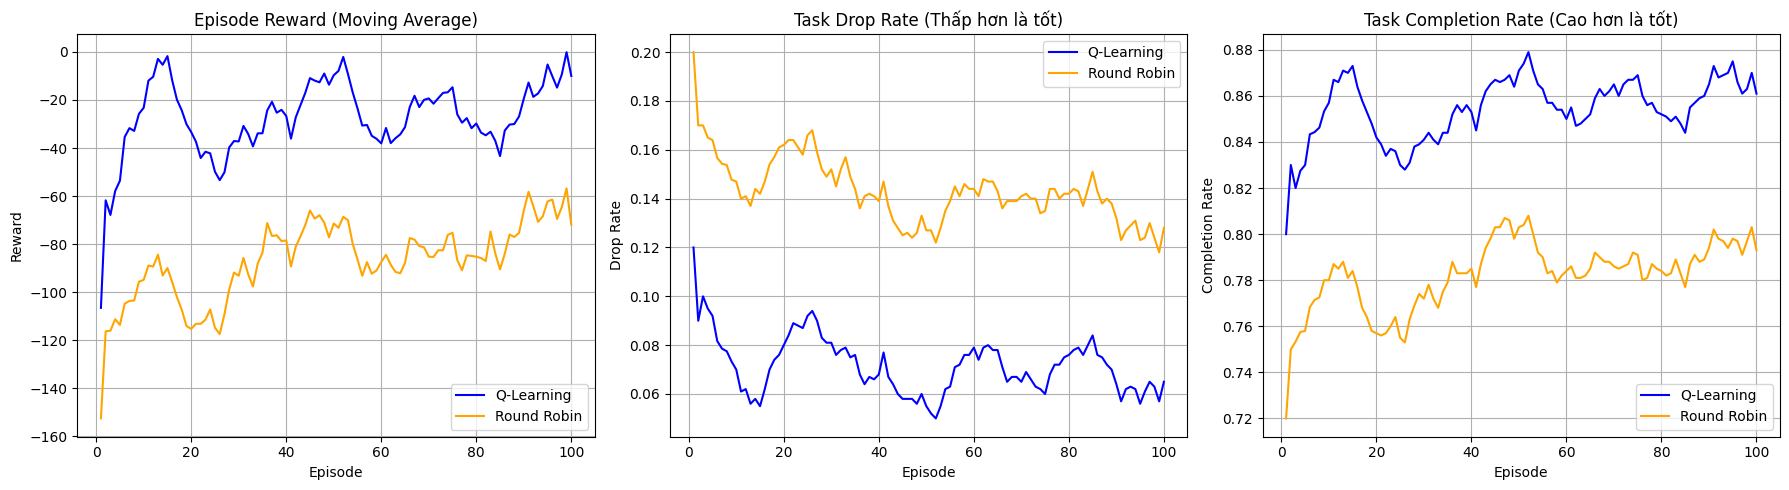

In [24]:
if __name__ == "__main__":
      # Create environment and reset initial state
      env = LoadBalancingEnv(n_servers=3, queue_capacity=2, seed=42)
      num_train_episodes = 5000
      steps_per_episode = 100

      print(f"1. Đang huấn luyện Q-Learning Agent ({num_train_episodes} episodes)...")
      agent = train_q_learning_agent(
            env,
            alpha=0.1,
            gamma=0.9,
            num_episodes=num_train_episodes,
            steps_per_episode=steps_per_episode,
            epsilon=0.1
      )

      print(f"Huấn luyện xong! Agent đã học được {len(agent.q_table)} trạng thái.")

      # ============================================================
      # BÀI 6 & 7: ĐÁNH GIÁ VÀ SO SÁNH (Q-LEARNING vs ROUND ROBIN)
      # ============================================================
      print("\n2. Đang tiến hành đánh giá 2 chiến lược trên 100 episode...")
      eval_episodes = 100
      eval_steps_per_episode = 100
      eval_seed_base = 2026
      
      # Hàm chạy 1 chiến lược và thu thập lịch sử
      def evaluate_policy(policy_name, \
                          num_episodes=eval_episodes, 
                          steps_per_episode=eval_steps_per_episode, 
                          seed_base=eval_seed_base):
            history = []

            for episode in range(num_episodes):
                  episode_seed = seed_base + episode
                  obs, _ = env.reset(seed=episode_seed)
                  if hasattr(env, 'rr_index'):
                        env.rr_index = 0 # Reset lại bộ đếm Round Robin cho công bằng

                  episode_reward = 0.0
                  state = obs
                  info = {}

                  for step in range(steps_per_episode):
                        if policy_name == "Q-learning":
                              # Dùng trí khôn 100% (Greedy Action), không random nữa
                              action = agent.choose_greedy_action(state)
                        else:
                              action = load_balancing_policy(option="round_robin", env=env)

                        next_obs, reward, terminated, truncated, info = env.step(action)
                        episode_reward += reward
                        state = next_obs

                  # Trích xuất dữ liệu tổng của episode cho bài báo cáo
                  total_runtime = info.get("time", steps_per_episode)
                  total_created = info.get("total_created tasks", 0)
                  accepted = info.get("accepted tasks", 0)
                  dropped = info.get("dropped tasks", 0)
                  completed = info.get("completed tasks", 0)
                  drop_rate = info.get("drop rate", 0.0)
                  completion_rate = info.get("completion rate", 0.0)

                  history.append({
                        "Episode": episode + 1,
                        "Policy": policy_name,
                        "Total_Runtime": total_runtime,
                        "Total_Created_Tasks": total_created,
                        "Accepted_Tasks": accepted,
                        "Dropped_Tasks": dropped,
                        "Completed_Tasks": completed,
                        "Reward": episode_reward,
                        "Drop_Rate": drop_rate,
                        "Completion_Rate": completion_rate
                  })

            return history

      # Chạy thu thập dữ liệu
      history_ql = evaluate_policy("Q-learning")
      history_rr = evaluate_policy("Round Robin")

      # Xuất ra file CSV theo yêu cầu
      df_ql, df_rr, summary_df = save_metrics(history_ql, history_rr)

      summary_ql = summarize_metrics(df_ql)
      summary_rr = summarize_metrics(df_rr)

      # In Bảng So Sánh theo format của đề bài
      print("\nBẢNG SO SÁNH HIỆU NĂNG TRÊN 100 EPISODE:")
      print(f"{'Metric':<20} | {'Q-learning':<15} | {'Round Robin':<15}")
      print("-" * 55)
      
      avg_reward_ql = summary_ql['Average Reward']
      avg_reward_rr = summary_rr['Average Reward']
      print(f"{'Average Reward':<20} | {avg_reward_ql:<15.2f} | {avg_reward_rr:<15.2f}")
      
      drop_rate_ql = summary_ql['Drop Rate']
      drop_rate_rr = summary_rr['Drop Rate']
      print(f"{'Drop Rate':<20} | {drop_rate_ql:<15.2%} | {drop_rate_rr:<15.2%}")
      
      comp_rate_ql = summary_ql['Completion Rate']
      comp_rate_rr = summary_rr['Completion Rate']
      print(f"{'Completion Rate':<20} | {comp_rate_ql:<15.2%} | {comp_rate_rr:<15.2%}")

      # Làm mượt biểu đồ để dễ quan sát xu hướng theo episode
      smoothing_window = 10
      plot_df_ql = df_ql.copy()
      plot_df_rr = df_rr.copy()
      for metric in ['Reward', 'Drop_Rate', 'Completion_Rate']:
            plot_df_ql[metric] = plot_df_ql[metric].rolling(window=smoothing_window, min_periods=1).mean()
            plot_df_rr[metric] = plot_df_rr[metric].rolling(window=smoothing_window, min_periods=1).mean()

      print("\n3. Biểu đồ thể hiện sự biến thiên của từng policy theo thời gian với 3 metrics: reward, drop, completion")

      # Vẽ 3 biểu đồ
      fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

      # Biểu đồ Reward
      ax1.plot(plot_df_ql['Episode'], plot_df_ql['Reward'], label='Q-Learning', color='blue')
      ax1.plot(plot_df_rr['Episode'], plot_df_rr['Reward'], label='Round Robin', color='orange')
      ax1.set_title('Episode Reward (Moving Average)')
      ax1.set_xlabel('Episode'); ax1.set_ylabel('Reward'); ax1.legend(); ax1.grid(True)

      # Biểu đồ Drop Rate
      ax2.plot(plot_df_ql['Episode'], plot_df_ql['Drop_Rate'], label='Q-Learning', color='blue')
      ax2.plot(plot_df_rr['Episode'], plot_df_rr['Drop_Rate'], label='Round Robin', color='orange')
      ax2.set_title('Task Drop Rate (Thấp hơn là tốt)')
      ax2.set_xlabel('Episode'); ax2.set_ylabel('Drop Rate'); ax2.legend(); ax2.grid(True)

      # Biểu đồ Completion Rate
      ax3.plot(plot_df_ql['Episode'], plot_df_ql['Completion_Rate'], label='Q-Learning', color='blue')
      ax3.plot(plot_df_rr['Episode'], plot_df_rr['Completion_Rate'], label='Round Robin', color='orange')
      ax3.set_title('Task Completion Rate (Cao hơn là tốt)')
      ax3.set_xlabel('Episode'); ax3.set_ylabel('Completion Rate'); ax3.legend(); ax3.grid(True)

      plt.tight_layout()
      plt.show()

Evaluation and Analysis